# Milestone 3, Task 4: Detection Visualization Gallery

This notebook renders the predictions of the fine-tuned YOLOv8 model on the held-out **test** split and assembles a
curated gallery of clear successes and instructive failures, each with a short caption.

* **Model and thresholds:** the checkpoint and operating point selected on the validation split by the
  hyperparameter sweep (`results/milestone3/sweep/best_model.pt` and `operating_point.json`, Task 3).
* **Error analysis:** every test prediction and every ground-truth face is labelled with the Task 2 matching protocol
  (same identity, IoU >= 0.5) and an error reason, see `src/detection_eval.py`:

| Outcome | Meaning |
|---|---|
| correct | box on the face with the right identity (IoU >= 0.5) |
| wrong identity | box on a face (IoU >= 0.5, or >= 0.3 if the identity is wrong) but with another person's name |
| duplicate | second box on a face that was already found |
| poor localization | right identity, but the box overlaps the face with IoU < 0.5 |
| background | box on no face at all |
| missed face | no box anywhere near a labelled face |

* **Selection:** the examples are chosen by rules on this table (listed in Part B), not by hand, so the gallery
  represents the model's actual error types and is reproducible.

**How to read the images.** Each prediction is a solid box in its identity color with the predicted name and confidence.
Errors are marked in red: an `x` after the label marks a wrong (or duplicate / badly placed) prediction, a dashed red box
marks a labelled face the model did not detect correctly (`MISSED`, or `true: <name>` when the face got another
person's name). Colors: <span style="color:#E69F00">■ id_2336</span> <span style="color:#56B4E9">■ id_2970</span>
<span style="color:#009E73">■ id_4422</span> <span style="color:#CC79A7">■ id_7007</span>.

**Outputs** (`results/milestone3/gallery/`): one annotated JPEG per example, `README.md` (the gallery with captions),
`contact_sheet.png` (all examples on one page), `test_error_analysis.csv` (one row per test face and prediction) and
`confusion_matrix.png`.

#### 0. Environment setup (local Jupyter or Google Colab)
Same cell as the other notebooks: on Colab it installs Ultralytics and mounts Drive, locally it finds the repo root.

In [1]:
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/rasmussenj03/IE7615-Group3-Project1.git"
COLAB_USE_DRIVE = True  # False -> clone into /content (outputs are lost when the runtime ends)
COLAB_REPO_DIR = ("/content/drive/MyDrive/IE7615-Group3-Project1" if COLAB_USE_DRIVE
                  else "/content/IE7615-Group3-Project1")

if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ultralytics>=8.3,<9"], check=True)
    if COLAB_USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
    if not Path(COLAB_REPO_DIR, "src").is_dir():
        from google.colab import userdata
        token = userdata.get("GITHUB_TOKEN")
        clone = subprocess.run(["git", "clone", "-q", REPO_URL.replace("https://", f"https://{token}@"),
                                COLAB_REPO_DIR], capture_output=True)
        if clone.returncode != 0:
            raise RuntimeError("git clone failed - check the GITHUB_TOKEN secret and repo access")
        subprocess.run(["git", "-C", COLAB_REPO_DIR, "remote", "set-url", "origin", REPO_URL])
    os.chdir(COLAB_REPO_DIR)
else:
    root = Path.cwd()
    while not (root / "src" / "detection_eval.py").exists() and root != root.parent:
        root = root.parent
    os.chdir(root)

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

Project root: C:\Users\masat\Documents\GitHub\IE7615-Group3-Project1


In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from ultralytics import YOLO

from src import detection_eval as de

SWEEP_DIR = PROJECT_ROOT / "results" / "milestone3" / "sweep"
GALLERY_DIR = PROJECT_ROOT / "results" / "milestone3" / "gallery"
OP = json.loads((SWEEP_DIR / "operating_point.json").read_text())
DEVICE = 0 if torch.cuda.is_available() else "cpu"
model = YOLO(str(PROJECT_ROOT / OP["model"]))
print("Operating point:", OP)

Operating point: {'model': 'results/milestone3/sweep/best_model.pt', 'training_run': 'aug_light', 'imgsz': 640, 'conf': 0.8, 'nms_iou': 0.7, 'agnostic_nms': False, 'selected_on': 'validation F1'}


---
## Part A: Predict the test split and label every outcome

In [3]:
TEST_IMAGES = de.split_images("test")
records = de.predict_split(model, TEST_IMAGES, nms_iou=OP["nms_iou"], agnostic_nms=OP["agnostic_nms"],
                           imgsz=OP["imgsz"], device=DEVICE)
analyses = {r["image"]: de.analyze_image(r, OP["conf"]) for r in records}
rec_by_name = {r["image"]: r for r in records}

rows = []
for r in records:
    a = analyses[r["image"]]
    for gi, (c, out) in enumerate(zip(r["gt_classes"], a["gt_outcome"])):
        rows.append(dict(image=r["image"], kind="ground truth", index=gi, identity=de.CLASS_NAMES[c],
                         outcome=out, iou=a["gt_iou"][gi], confidence=np.nan,
                         box_height=r["gt_boxes"][gi, 3] - r["gt_boxes"][gi, 1]))
    for pi, (c, s, out, gi) in enumerate(zip(a["classes"], a["scores"], a["pred_outcome"], a["pred_gt"])):
        rows.append(dict(image=r["image"], kind="prediction", index=pi, identity=de.CLASS_NAMES[c], outcome=out,
                         true_identity=de.CLASS_NAMES[r["gt_classes"][gi]] if gi is not None else None,
                         iou=float(de.box_iou(a["boxes"][pi], r["gt_boxes"][gi])[0, 0]) if gi is not None else 0.0,
                         confidence=float(s), box_height=a["boxes"][pi, 3] - a["boxes"][pi, 1]))
table = pd.DataFrame(rows)
GALLERY_DIR.mkdir(parents=True, exist_ok=True)
table.round(4).to_csv(GALLERY_DIR / "test_error_analysis.csv", index=False)

overall, per_class = de.evaluate(records, OP["conf"])
print(f"Test split at the operating point: precision {overall['precision']:.3f}, recall {overall['recall']:.3f}, "
      f"F1 {overall['F1']:.3f}, mean matched IoU {overall['mean_matched_IoU']:.3f}")
display(pd.crosstab([table.kind, table.outcome], table.image.str.contains("_aug_").map(
    {False: "original", True: "augmented"})).rename_axis(columns="image type"))

Test split at the operating point: precision 0.965, recall 0.919, F1 0.942, mean matched IoU 0.971


image type                   augmented  original
kind         outcome                            
ground truth confused               11         5
             found                 210       289
             missed                 19         9
prediction   TP                    210       289
             background              2         0
             wrong_identity         11         5

**Identity confusion matrix.** Rows are the true identity of each labelled test face, columns what the model said:
the identity of the box that matched it (IoU >= 0.5, any identity, highest confidence first), or *missed* when no box
covered it.

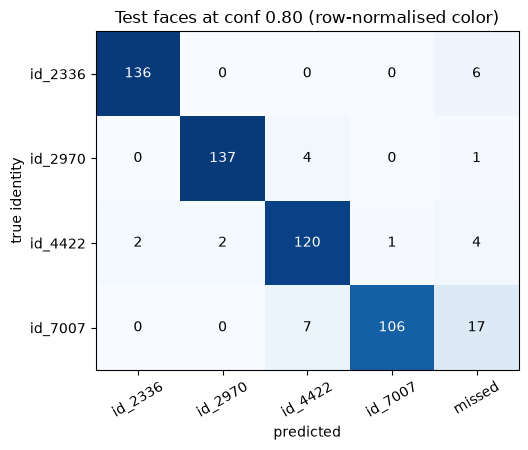

In [4]:
labels = de.CLASS_NAMES + ["missed"]
cm = pd.DataFrame(0, index=de.CLASS_NAMES, columns=labels)
for r in records:
    a = analyses[r["image"]]
    ious = de.box_iou(r["gt_boxes"], a["boxes"]) if len(a["boxes"]) else np.zeros((len(r["gt_boxes"]), 0))
    for gi, c in enumerate(r["gt_classes"]):
        cands = [pi for pi in range(ious.shape[1]) if ious[gi, pi] >= de.MATCH_IOU]
        pred = labels[a["classes"][max(cands, key=lambda p: a["scores"][p])]] if cands else "missed"
        cm.loc[de.CLASS_NAMES[c], pred] += 1
fig, ax = plt.subplots(figsize=(6.2, 4.6))
ax.imshow(cm.values / cm.values.sum(axis=1, keepdims=True), cmap="Blues", vmin=0, vmax=1)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        v = cm.values[i, j]
        ax.text(j, i, v, ha="center", va="center", color="white" if v > cm.values[i].sum() / 2 else "black")
ax.set_xticks(range(len(labels)), labels, rotation=30); ax.set_yticks(range(4), de.CLASS_NAMES)
ax.set(xlabel="predicted", ylabel="true identity",
       title=f"Test faces at conf {OP['conf']:.2f} (row-normalised color)")
fig.tight_layout(); fig.savefig(GALLERY_DIR / "confusion_matrix.png", dpi=150); plt.show()

---
## Part B: Select the gallery examples

Each image gets a set of tags from the error table. The gallery then takes images per category, in a fixed order,
without repeating an image:

| Category | Rule (test split, at the operating point unless stated) | Images |
|---|---|---|
| Success: crowded scene | original image, 4 faces, all correct, no extra boxes; highest minimum confidence | 2 |
| Success: augmented scene | augmented image (crop, flip, dropout holes, rotation, grey), all faces correct | 2 |
| Success: small faces | all correct; smallest face height in the image | 1 |
| Failure: identity confusion | a face boxed with another identity | 3 |
| Failure: missed face | a labelled face without a box above the threshold | 2 |
| Failure: duplicate / loose box | duplicate box, or right identity with IoU < 0.5 | up to 2 |
| Failure: background false alarm | a box on no labelled face | up to 1 |
| Failure: more errors | if a category above has too few images, the remaining images with the most errors | fills the gap |
| Threshold effect | original image with the most background boxes at the **Task 2 default confidence 0.25**, drawn at 0.25 | 1 |
| Borderline: low-confidence hit | correct, but with the lowest-confidence true positive in the split | 1 |

In [5]:
LOW_CONF = 0.25  # Task 2 default, used for the threshold-effect example
low = {r["image"]: de.analyze_image(r, LOW_CONF) for r in records}

def image_summary(name):
    r, a = rec_by_name[name], analyses[name]
    tp_scores = [s for s, o in zip(a["scores"], a["pred_outcome"]) if o == "TP"]
    heights = r["gt_boxes"][:, 3] - r["gt_boxes"][:, 1]
    return dict(image=name, augmented="_aug_" in name, faces=len(r["gt_classes"]),
                all_correct=all(o == "found" for o in a["gt_outcome"]) and all(o == "TP" for o in a["pred_outcome"]),
                n_wrong=a["pred_outcome"].count("wrong_identity"),
                n_missed=a["gt_outcome"].count("missed") + a["gt_outcome"].count("poorly_localized"),
                n_dup_loc=a["pred_outcome"].count("duplicate") + a["pred_outcome"].count("poor_localization"),
                n_background=a["pred_outcome"].count("background"),
                n_background_low=low[name]["pred_outcome"].count("background"),
                min_tp_conf=min(tp_scores) if tp_scores else 0.0,
                min_face_px=float(heights.min() * 640 / r["size"][0]))

summ = pd.DataFrame([image_summary(r["image"]) for r in records]).set_index("image")
summ["n_errors"] = summ[["n_wrong", "n_missed", "n_dup_loc", "n_background"]].sum(axis=1)

def primary_error(row):
    for col, key, title in [("n_wrong", "fail_identity", "Failure: identity confusion"),
                            ("n_missed", "fail_missed", "Failure: missed face"),
                            ("n_dup_loc", "fail_dup_loc", "Failure: duplicate / loose box"),
                            ("n_background", "fail_background", "Failure: background false alarm")]:
        if row[col] > 0:
            return key, title

CATEGORIES = [  # (key, title, candidates sorted best-first, quota)
    ("success_crowded", "Success: crowded scene",
     summ[summ.all_correct & ~summ.augmented & (summ.faces == 4)].sort_values("min_tp_conf", ascending=False), 2),
    ("success_augmented", "Success: augmented scene",
     summ[summ.all_correct & summ.augmented & (summ.faces >= 2)].sort_values(["faces", "min_tp_conf"],
                                                                            ascending=False), 2),
    ("success_small", "Success: small faces",
     summ[summ.all_correct & (summ.faces >= 2)].sort_values("min_face_px"), 1),
    ("fail_identity", "Failure: identity confusion",
     summ[summ.n_wrong > 0].sort_values(["n_wrong", "faces"], ascending=False), 3),
    ("fail_missed", "Failure: missed face", summ[summ.n_missed > 0].sort_values("n_missed", ascending=False), 2),
    ("fail_dup_loc", "Failure: duplicate / loose box",
     summ[summ.n_dup_loc > 0].sort_values("n_dup_loc", ascending=False), 2),
    ("fail_background", "Failure: background false alarm", summ[summ.n_background > 0], 1),
    ("fail_more", None, summ[summ.n_errors > 0].sort_values(["n_errors", "faces"], ascending=False), 0),
    ("threshold", f"Threshold effect: confidence {LOW_CONF}",
     summ[~summ.augmented].sort_values("n_background_low", ascending=False), 1),
    ("borderline", "Borderline: low-confidence hit",
     summ[(summ.n_errors == 0) & (summ.min_tp_conf > 0)].sort_values("min_tp_conf"), 1),
]
picked, used, shortfall = [], set(), 0
for key, title, cands, quota in CATEGORIES:
    cands = [n for n in cands.index if n not in used]
    if key == "fail_more":
        quota = shortfall
    chosen = cands[:quota]
    if key.startswith("fail") and key != "fail_more":
        shortfall += quota - len(chosen)
    for n in chosen:
        used.add(n)
        k, t = primary_error(summ.loc[n]) if key == "fail_more" else (key, title)
        picked.append((k, t, n))
gallery = pd.DataFrame(picked, columns=["category", "title", "image"])
display(gallery.join(summ, on="image"))
assert len(gallery) >= 10

,category,title,image,augmented,faces,all_correct,n_wrong,n_missed,n_dup_loc,n_background,n_background_low,min_tp_conf,min_face_px,n_errors
0,success_crowded,Success: crowded scene,test_0066.jpg,False,4,True,0,0,0,0,0,0.979572,119.00032,0
1,success_crowded,Success: crowded scene,test_0010.jpg,False,4,True,0,0,0,0,0,0.978651,119.00032,0
2,success_augmented,Success: augmented scene,test_aug_0051.jpg,True,4,True,0,0,0,0,0,0.967473,194.84416,0
3,success_augmented,Success: augmented scene,test_aug_0068.jpg,True,4,True,0,0,0,0,0,0.956819,146.48896,0
4,success_small,Success: small faces,test_0069.jpg,False,3,True,0,0,0,0,0,0.968050,90.00000,0
5,fail_identity,Failure: identity confusion,test_aug_0077.jpg,True,3,False,2,0,0,0,0,0.977096,156.44416,2
6,fail_identity,Failure: identity confusion,test_0082.jpg,False,4,False,1,0,0,0,1,0.974637,114.00000,1
7,fail_identity,Failure: identity confusion,test_0100.jpg,False,4,False,1,0,0,0,0,0.973683,96.99968,1
8,fail_missed,Failure: missed face,test_aug_0056.jpg,True,4,False,0,2,0,0,0,0.946227,133.68896,2
9,fail_missed,Failure: missed face,test_0023.jpg,False,4,False,0,1,0,0,0,0.965552,92.00000,1


---
## Part C: Render, caption and save the gallery

Captions are generated from the error table: what was predicted, how confident it was, and what went wrong. For a
missed face, the caption also gives the model's best box on that face *below* the threshold, if there is one, which
tells a threshold miss apart from a face the model does not see at all. The short notes in `NOTES` were written after
looking at the rendered images and are keyed by image name; a note is only shown when its image is selected.

In [6]:
def describe(name, a, conf):
    """One-sentence factual caption from the error table."""
    r = rec_by_name[name]
    kind = "augmented copy" if "_aug_" in name else "original scene"
    parts = [f"{kind}, {len(r['gt_classes'])} labelled face{'s' if len(r['gt_classes']) != 1 else ''}"]
    found = [(de.CLASS_NAMES[a["classes"][pi]], a["scores"][pi]) for pi, o in enumerate(a["pred_outcome"]) if o == "TP"]
    if len(found) > 1:
        lo, hi = min(s for _, s in found), max(s for _, s in found)
        parts.append(f"{len(found)} found correctly (confidence {lo:.2f}" + (f"-{hi:.2f})" if f"{hi:.2f}" != f"{lo:.2f}" else ")"))
    elif found:
        parts.append(f"1 found correctly ({found[0][0]}, {found[0][1]:.2f})")
    for pi, o in enumerate(a["pred_outcome"]):
        name_p, s, gi = de.CLASS_NAMES[a["classes"][pi]], a["scores"][pi], a["pred_gt"][pi]
        true = de.CLASS_NAMES[r["gt_classes"][gi]] if gi is not None else None
        if o == "wrong_identity":
            parts.append(f"**{true} predicted as {name_p}** ({s:.2f})")
        elif o == "duplicate":
            parts.append(f"**duplicate {name_p} box** on an already detected face ({s:.2f})")
        elif o == "poor_localization":
            iou = de.box_iou(a["boxes"][pi], r["gt_boxes"][gi])[0, 0]
            parts.append(f"**{name_p} box too loose/offset** (IoU {iou:.2f} < 0.5, conf {s:.2f})")
    bg = sorted(((s, de.CLASS_NAMES[c]) for s, c, o in zip(a["scores"], a["classes"], a["pred_outcome"])
                 if o == "background"), reverse=True)
    if bg:
        parts.append(f"**{len(bg)} box{'es' if len(bg) > 1 else ''} on no labelled face** ("
                     + ", ".join(f"{c} {s:.2f}" for s, c in bg) + ")")
    for gi, o in enumerate(a["gt_outcome"]):
        if o in ("missed", "poorly_localized"):
            name_t = de.CLASS_NAMES[r["gt_classes"][gi]]
            h = (r["gt_boxes"][gi, 3] - r["gt_boxes"][gi, 1]) * 640 / r["size"][0]
            ious = de.box_iou(r["gt_boxes"][gi], r["boxes"])[0] if len(r["boxes"]) else np.zeros(0)
            below = [(r["scores"][pi], de.CLASS_NAMES[r["classes"][pi]]) for pi in range(len(ious))
                     if ious[pi] >= de.MATCH_IOU and r["scores"][pi] < conf]
            hint = (f"the model's best box on it is {max(below)[1]} at {max(below)[0]:.2f}, below the threshold"
                    if below else "no box on it even at confidence 0.001")
            parts.append(f"**{name_t} missed** ({h:.0f} px tall; {hint})")
    return "; ".join(parts) + "."

# Written after reviewing the rendered gallery (keyed by image name).
NOTES = {
    "test_0066.jpg": "All four identities in one room, each named correctly at 0.98: the typical result on original scenes.",
    "test_0010.jpg": "Three faces close together (without overlapping) still get tight, separate boxes.",
    "test_aug_0051.jpg": "Grey-scale copy with a dropout hole on id_7007's face and id_2970 cut by the top-left border: "
                         "identity is recognized without color and with partial occlusion.",
    "test_aug_0068.jpg": "Several dropout holes, and faces at the bottom-left and right borders, are all handled correctly.",
    "test_0069.jpg": "The smallest face in this selection (id_4422 on the right, about 90 px tall) is still found and "
                     "named correctly.",
    "test_aug_0077.jpg": "The Milestone 1 look-alike pair (id_2970 / id_4422) swapped in both directions, with high "
                         "confidence: the id_2970 face is cut by the left border and the id_4422 face has a dropout "
                         "hole. Raising the threshold cannot fix confident confusions like these.",
    "test_0082.jpg": "id_7007 predicted as id_4422 is the detector's most frequent confusion on test (7 of 16 "
                     "wrong-identity boxes, see the confusion matrix); here on an unaugmented face, with 0.96 confidence.",
    "test_0100.jpg": "The same confusion (id_7007 as id_4422) in the same room, at lower confidence (0.87).",
    "test_aug_0056.jpg": "Both misses are threshold misses: the model does box these faces, at 0.74-0.76, just under "
                         "0.80. One is a small grey-scale face; the other is cut by the right border and boxed under "
                         "the wrong name.",
    "test_0023.jpg": "A fully visible, unaugmented id_7007 face missed at 0.80; the model's best box on it says id_4422 "
                     "at 0.64. id_7007 faces are often split between id_7007 and id_4422 at moderate confidence, "
                     "which is why id_7007 has the lowest test recall (0.815).",
    "test_aug_0027.jpg": "The 'false alarm' on the right is a correct id_2336 face cut by the crop: the original scene "
                         "(test_0027) labels id_2336 there, but Milestone 2 dropped the label in this copy because less "
                         "than 30% of the box remained (min_visibility 0.3). A labelling artefact, not a model error.",
    "test_aug_0012.jpg": "Rotation and the crop push two faces together at the right border: id_7007 is almost "
                         "entirely cut off, and its loose rotated box overlaps the id_4422 face, which is named id_2336 "
                         "(0.81). The only overlapping faces in this selection; Milestone 2 composes scenes without "
                         "overlap, so they only arise from augmentation.",
    "test_aug_0023.jpg": "Occlusion: dropout holes over the eye and mouth of id_4422 lead to id_7007 (0.94), and a hole "
                         "over the top of id_2336's head leaves only a 0.20 box. The face is still located, but the "
                         "identity cues are gone.",
    "test_0084.jpg": "Chair backs at head height: the grey backrests in this test room are face-sized and roughly oval, "
                     "and at the default threshold the model boxes three of them as id_7007 (0.41-0.60). Chair backs were "
                     "behind every interior test false positive we inspected (46 at 0.25 in total, against 2 on "
                     "validation); the validation-selected threshold of 0.80 removes them all.",
    "test_aug_0079.jpg": "The lowest-confidence correct detection in the split (id_2970 at 0.80, cut by the left border) "
                         "sits right at the threshold: a slightly stricter setting would turn it into a miss.",
}

for old in GALLERY_DIR.glob("[0-9][0-9]_*.jpg"):
    old.unlink()
entries = []
for i, (key, title, name) in enumerate(gallery.itertuples(index=False), start=1):
    a, conf = (low[name], LOW_CONF) if key == "threshold" else (analyses[name], OP["conf"])
    file = f"{i:02d}_{key}_{Path(name).stem}.jpg"
    de.render(rec_by_name[name], a).save(GALLERY_DIR / file, quality=92)
    caption = describe(name, a, conf)
    if key == "threshold":
        caption = (f"Drawn at confidence {LOW_CONF} instead of {OP['conf']:.2f}: " + caption +
                   f" At the operating point, {analyses[name]['pred_outcome'].count('background')} of these remain.")
    entries.append(dict(file=file, image=name, category=title, caption=caption, note=NOTES.get(name, "")))
entries = pd.DataFrame(entries)
entries.to_csv(GALLERY_DIR / "captions.csv", index=False)
pd.set_option("display.max_colwidth", None)
display(entries[["file", "category", "caption"]])

,file,category,caption
0,01_success_crowded_test_0066.jpg,Success: crowded scene,"original scene, 4 labelled faces; 4 found correctly (confidence 0.98)."
1,02_success_crowded_test_0010.jpg,Success: crowded scene,"original scene, 4 labelled faces; 4 found correctly (confidence 0.98-0.99)."
2,03_success_augmented_test_aug_0051.jpg,Success: augmented scene,"augmented copy, 4 labelled faces; 4 found correctly (confidence 0.97)."
3,04_success_augmented_test_aug_0068.jpg,Success: augmented scene,"augmented copy, 4 labelled faces; 4 found correctly (confidence 0.96-0.98)."
4,05_success_small_test_0069.jpg,Success: small faces,"original scene, 3 labelled faces; 3 found correctly (confidence 0.97-0.98)."
5,06_fail_identity_test_aug_0077.jpg,Failure: identity confusion,"augmented copy, 3 labelled faces; 1 found correctly (id_2336, 0.98); **id_2970 predicted as id_4422** (0.92); **id_4422 predicted as id_2970** (0.89)."
6,07_fail_identity_test_0082.jpg,Failure: identity confusion,"original scene, 4 labelled faces; 3 found correctly (confidence 0.97-0.98); **id_7007 predicted as id_4422** (0.96)."
7,08_fail_identity_test_0100.jpg,Failure: identity confusion,"original scene, 4 labelled faces; 3 found correctly (confidence 0.97-0.98); **id_7007 predicted as id_4422** (0.87)."
8,09_fail_missed_test_aug_0056.jpg,Failure: missed face,"augmented copy, 4 labelled faces; 2 found correctly (confidence 0.95-0.97); **id_7007 missed** (134 px tall; the model's best box on it is id_7007 at 0.76, below the threshold); **id_2336 missed** (257 px tall; the model's best box on it is id_7007 at 0.74, below the threshold)."
9,10_fail_missed_test_0023.jpg,Failure: missed face,"original scene, 4 labelled faces; 3 found correctly (confidence 0.97-0.98); **id_7007 missed** (140 px tall; the model's best box on it is id_4422 at 0.64, below the threshold)."


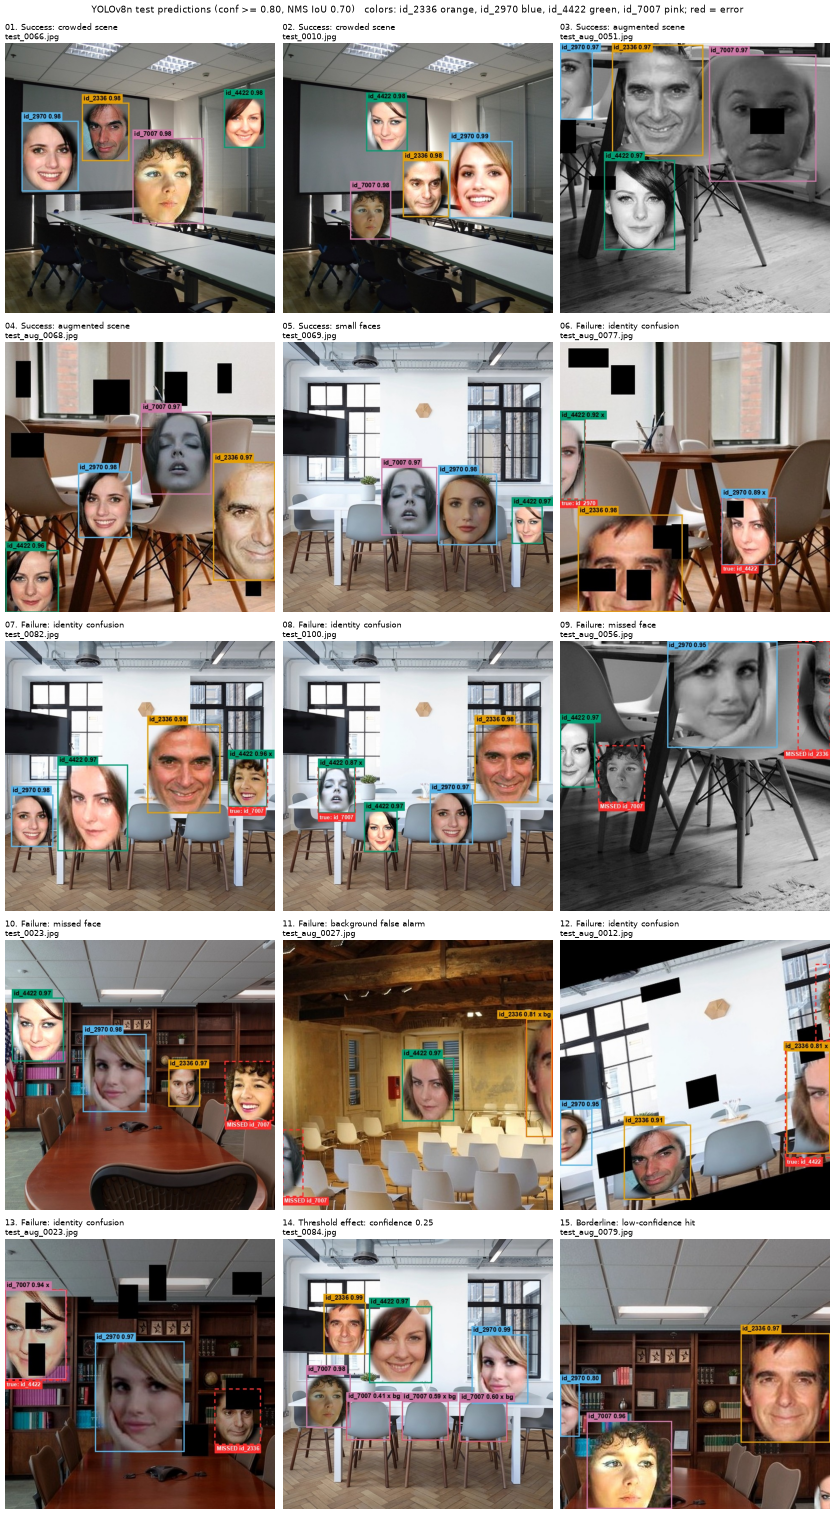

In [7]:
cols = 3
rows_n = int(np.ceil(len(entries) / cols))
fig, axes = plt.subplots(rows_n, cols, figsize=(cols * 5.6, rows_n * 6.2), dpi=50)  # small inline copy
for ax in axes.flat:
    ax.axis("off")
for ax, e in zip(axes.flat, entries.itertuples()):
    ax.imshow(plt.imread(GALLERY_DIR / e.file))
    ax.set_title(f"{e.file[:2]}. {e.category}\n{e.image}", fontsize=11, loc="left")
fig.suptitle(f"YOLOv8n test predictions (conf >= {OP['conf']:.2f}, NMS IoU {OP['nms_iou']:.2f}"
             f"{', class-agnostic' if OP['agnostic_nms'] else ''})   "
             "colors: id_2336 orange, id_2970 blue, id_4422 green, id_7007 pink; red = error", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.985))
fig.savefig(GALLERY_DIR / "contact_sheet.png", dpi=80)
plt.show()

In [8]:
# Interpretation, written after reviewing the gallery and the error table.
SUMMARY = """
Successes cover every identity in crowded original scenes and in augmented copies with
grey-scale, crop borders and dropout holes. The failures fall into four patterns, which match the error counts of the
sweep (Task 3):

1. **Confident identity confusions** (examples 6-8, 12-13): mostly id_7007 → id_4422 and the id_2970 / id_4422
   look-alike pair, at 0.81-0.96. A higher confidence threshold cannot remove these; it would take a better
   identity representation (e.g. the Milestone 1 classifier on the detected crops in Milestone 4) or more varied
   training faces.
2. **Threshold misses** (examples 9-11): faces boxed at 0.6-0.8 and dropped by the 0.80 threshold, mostly id_7007. This
   is the recall paid for the precision gain at the operating point.
3. **Occlusion and crop borders** (examples 9, 11-13): dropout holes over the eyes or mouth, and faces cut by the
   augmentation crop, either break identity or fall below the threshold. Example 11 also shows that a few "false
   positives" are correct detections of cut faces whose labels Milestone 2 removed.
4. **Chair backs at head height** (example 14): the only real background errors. They appear only below the operating
   threshold and only in test rooms with rows of chairs, so the detector partly learned "oval patch at head height".
   Backgrounds with people-like clutter would be a useful addition to the training data.

Localization is not a failure mode: correct boxes have a mean IoU of 0.97 with the labels, and no "loose box" or
duplicate errors remain at the operating point. **Overlapping faces** occur only where augmentation pushes faces
together (example 12), because Milestone 2 placed faces without overlap; real group photos would test this much harder.
"""

lines = [
    "# Detection Visualization Gallery (Milestone 3, Task 4)", "",
    f"Predictions of the fine-tuned YOLOv8n (`{OP['model']}`, training run `{OP['training_run']}`) on held-out "
    f"**test** images, at the operating point selected on the validation split: confidence >= {OP['conf']:.2f}, "
    f"NMS IoU {OP['nms_iou']:.2f}, {'class-agnostic' if OP['agnostic_nms'] else 'class-aware'} NMS, "
    f"image size {OP['imgsz']}. Generated by "
    "[`milestone3/Detection_Gallery.ipynb`](../../../milestone3/Detection_Gallery.ipynb); examples are selected by "
    "fixed rules on the error table, not by hand.", "",
    f"On the whole test split (200 images, {int(overall['TP'] + overall['FN'])} faces) the model reaches precision "
    f"{overall['precision']:.3f}, recall {overall['recall']:.3f} and mean matched IoU "
    f"{overall['mean_matched_IoU']:.3f} at this operating point.", "",
    "**Legend.** Solid box = prediction, in the color of the predicted identity "
    "(id_2336 orange, id_2970 blue, id_4422 green, id_7007 pink), labelled with name and confidence. "
    "Red marks errors: `x` = wrong identity, `x dup` = duplicate, `x loc` = box overlaps the face with IoU < 0.5, "
    "`x bg` = box on background; a dashed red box is a labelled face that was missed (`MISSED`) or only boxed under "
    "another name (`true: <name>`).", "",
    "![contact sheet](contact_sheet.png)", "",
    "| # | Category | Image | Caption |", "|---|---|---|---|",
]
for i, e in enumerate(entries.itertuples(), start=1):
    caption = e.caption + (f" {e.note}" if e.note else "")
    lines.append(f"| {i} | {e.category} | [`{e.image}`]({e.file}) | {caption} |")
lines += ["", "Identity confusion on the full test split:", "", "![confusion matrix](confusion_matrix.png)", "",
          "Full per-face and per-prediction outcomes: [`test_error_analysis.csv`](test_error_analysis.csv).",
          "", "## What the gallery shows", "", SUMMARY.strip()]
(GALLERY_DIR / "README.md").write_text("\n".join(lines) + "\n", encoding="utf-8")
display(Markdown("\n".join(lines[lines.index("| # | Category | Image | Caption |"):])))

| # | Category | Image | Caption |
|---|---|---|---|
| 1 | Success: crowded scene | [`test_0066.jpg`](01_success_crowded_test_0066.jpg) | original scene, 4 labelled faces; 4 found correctly (confidence 0.98). All four identities in one room, each named correctly at 0.98: the typical result on original scenes. |
| 2 | Success: crowded scene | [`test_0010.jpg`](02_success_crowded_test_0010.jpg) | original scene, 4 labelled faces; 4 found correctly (confidence 0.98-0.99). Three faces close together (without overlapping) still get tight, separate boxes. |
| 3 | Success: augmented scene | [`test_aug_0051.jpg`](03_success_augmented_test_aug_0051.jpg) | augmented copy, 4 labelled faces; 4 found correctly (confidence 0.97). Grey-scale copy with a dropout hole on id_7007's face and id_2970 cut by the top-left border: identity is recognized without color and with partial occlusion. |
| 4 | Success: augmented scene | [`test_aug_0068.jpg`](04_success_augmented_test_aug_0068.jpg) | augmented copy, 4 labelled faces; 4 found correctly (confidence 0.96-0.98). Several dropout holes, and faces at the bottom-left and right borders, are all handled correctly. |
| 5 | Success: small faces | [`test_0069.jpg`](05_success_small_test_0069.jpg) | original scene, 3 labelled faces; 3 found correctly (confidence 0.97-0.98). The smallest face in this selection (id_4422 on the right, about 90 px tall) is still found and named correctly. |
| 6 | Failure: identity confusion | [`test_aug_0077.jpg`](06_fail_identity_test_aug_0077.jpg) | augmented copy, 3 labelled faces; 1 found correctly (id_2336, 0.98); **id_2970 predicted as id_4422** (0.92); **id_4422 predicted as id_2970** (0.89). The Milestone 1 look-alike pair (id_2970 / id_4422) swapped in both directions, with high confidence: the id_2970 face is cut by the left border and the id_4422 face has a dropout hole. Raising the threshold cannot fix confident confusions like these. |
| 7 | Failure: identity confusion | [`test_0082.jpg`](07_fail_identity_test_0082.jpg) | original scene, 4 labelled faces; 3 found correctly (confidence 0.97-0.98); **id_7007 predicted as id_4422** (0.96). id_7007 predicted as id_4422 is the detector's most frequent confusion on test (7 of 16 wrong-identity boxes, see the confusion matrix); here on an unaugmented face, with 0.96 confidence. |
| 8 | Failure: identity confusion | [`test_0100.jpg`](08_fail_identity_test_0100.jpg) | original scene, 4 labelled faces; 3 found correctly (confidence 0.97-0.98); **id_7007 predicted as id_4422** (0.87). The same confusion (id_7007 as id_4422) in the same room, at lower confidence (0.87). |
| 9 | Failure: missed face | [`test_aug_0056.jpg`](09_fail_missed_test_aug_0056.jpg) | augmented copy, 4 labelled faces; 2 found correctly (confidence 0.95-0.97); **id_7007 missed** (134 px tall; the model's best box on it is id_7007 at 0.76, below the threshold); **id_2336 missed** (257 px tall; the model's best box on it is id_7007 at 0.74, below the threshold). Both misses are threshold misses: the model does box these faces, at 0.74-0.76, just under 0.80. One is a small grey-scale face; the other is cut by the right border and boxed under the wrong name. |
| 10 | Failure: missed face | [`test_0023.jpg`](10_fail_missed_test_0023.jpg) | original scene, 4 labelled faces; 3 found correctly (confidence 0.97-0.98); **id_7007 missed** (140 px tall; the model's best box on it is id_4422 at 0.64, below the threshold). A fully visible, unaugmented id_7007 face missed at 0.80; the model's best box on it says id_4422 at 0.64. id_7007 faces are often split between id_7007 and id_4422 at moderate confidence, which is why id_7007 has the lowest test recall (0.815). |
| 11 | Failure: background false alarm | [`test_aug_0027.jpg`](11_fail_background_test_aug_0027.jpg) | augmented copy, 2 labelled faces; 1 found correctly (id_4422, 0.97); **1 box on no labelled face** (id_2336 0.81); **id_7007 missed** (158 px tall; the model's best box on it is id_4422 at 0.76, below the threshold). The 'false alarm' on the right is a correct id_2336 face cut by the crop: the original scene (test_0027) labels id_2336 there, but Milestone 2 dropped the label in this copy because less than 30% of the box remained (min_visibility 0.3). A labelling artefact, not a model error. |
| 12 | Failure: identity confusion | [`test_aug_0012.jpg`](12_fail_identity_test_aug_0012.jpg) | augmented copy, 4 labelled faces; 2 found correctly (confidence 0.91-0.95); **id_4422 predicted as id_2336** (0.81); **id_7007 missed** (181 px tall; the model's best box on it is id_2970 at 0.34, below the threshold). Rotation and the crop push two faces together at the right border: id_7007 is almost entirely cut off, and its loose rotated box overlaps the id_4422 face, which is named id_2336 (0.81). The only overlapping faces in this selection; Milestone 2 composes scenes without overlap, so they only arise from augmentation. |
| 13 | Failure: identity confusion | [`test_aug_0023.jpg`](13_fail_identity_test_aug_0023.jpg) | augmented copy, 3 labelled faces; 1 found correctly (id_2970, 0.97); **id_4422 predicted as id_7007** (0.94); **id_2336 missed** (131 px tall; the model's best box on it is id_7007 at 0.20, below the threshold). Occlusion: dropout holes over the eye and mouth of id_4422 lead to id_7007 (0.94), and a hole over the top of id_2336's head leaves only a 0.20 box. The face is still located, but the identity cues are gone. |
| 14 | Threshold effect: confidence 0.25 | [`test_0084.jpg`](14_threshold_test_0084.jpg) | Drawn at confidence 0.25 instead of 0.80: original scene, 4 labelled faces; 4 found correctly (confidence 0.97-0.99); **3 boxes on no labelled face** (id_7007 0.60, id_7007 0.59, id_7007 0.41). At the operating point, 0 of these remain. Chair backs at head height: the grey backrests in this test room are face-sized and roughly oval, and at the default threshold the model boxes three of them as id_7007 (0.41-0.60). Chair backs were behind every interior test false positive we inspected (46 at 0.25 in total, against 2 on validation); the validation-selected threshold of 0.80 removes them all. |
| 15 | Borderline: low-confidence hit | [`test_aug_0079.jpg`](15_borderline_test_aug_0079.jpg) | augmented copy, 3 labelled faces; 3 found correctly (confidence 0.80-0.97). The lowest-confidence correct detection in the split (id_2970 at 0.80, cut by the left border) sits right at the threshold: a slightly stricter setting would turn it into a miss. |

Identity confusion on the full test split:

![confusion matrix](confusion_matrix.png)

Full per-face and per-prediction outcomes: [`test_error_analysis.csv`](test_error_analysis.csv).

## What the gallery shows

Successes cover every identity in crowded original scenes and in augmented copies with
grey-scale, crop borders and dropout holes. The failures fall into four patterns, which match the error counts of the
sweep (Task 3):

1. **Confident identity confusions** (examples 6-8, 12-13): mostly id_7007 → id_4422 and the id_2970 / id_4422
   look-alike pair, at 0.81-0.96. A higher confidence threshold cannot remove these; it would take a better
   identity representation (e.g. the Milestone 1 classifier on the detected crops in Milestone 4) or more varied
   training faces.
2. **Threshold misses** (examples 9-11): faces boxed at 0.6-0.8 and dropped by the 0.80 threshold, mostly id_7007. This
   is the recall paid for the precision gain at the operating point.
3. **Occlusion and crop borders** (examples 9, 11-13): dropout holes over the eyes or mouth, and faces cut by the
   augmentation crop, either break identity or fall below the threshold. Example 11 also shows that a few "false
   positives" are correct detections of cut faces whose labels Milestone 2 removed.
4. **Chair backs at head height** (example 14): the only real background errors. They appear only below the operating
   threshold and only in test rooms with rows of chairs, so the detector partly learned "oval patch at head height".
   Backgrounds with people-like clutter would be a useful addition to the training data.

Localization is not a failure mode: correct boxes have a mean IoU of 0.97 with the labels, and no "loose box" or
duplicate errors remain at the operating point. **Overlapping faces** occur only where augmentation pushes faces
together (example 12), because Milestone 2 placed faces without overlap; real group photos would test this much harder.